# Global Setup and Initialization
In this section, we import all necessary libraries, set the global random seed (7) for absolute reproducibility, and configure the compute device.

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import random
import math
import time
import matplotlib.pyplot as plt
import nltk
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
from thop import profile, clever_format

# 1. Reproducibility Seed
def set_seed(seed=7):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    print(f"[*] Global seed set to: {seed}")

set_seed(7)

# 2. Hardware Configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[*] Compute Device: {device}")
if torch.cuda.is_available():
    print(f"[*] GPU Detected: {torch.cuda.get_device_name(0)}")

[*] Global seed set to: 7
[*] Compute Device: cuda
[*] GPU Detected: NVIDIA GeForce RTX 4060 Laptop GPU


# Data Pipeline: Tokenization & Strict Splitting
We define our Vocabulary class, read the dataset directly from the Downloads folder, and perform the exact same 80/20 train/validation split used in Problem 1. Using the same random seed ensures the data is shuffled and split identically.

In [7]:
# Special Tokens
SOS_token = 0  
EOS_token = 1  
PAD_token = 2  
UNK_token = 3  

class Vocabulary:
    def __init__(self, name):
        self.name = name
        self.word2index = {"<SOS>": 0, "<EOS>": 1, "<PAD>": 2, "<UNK>": 3}
        self.word2count = {}
        self.index2word = {0: "<SOS>", 1: "<EOS>", 2: "<PAD>", 3: "<UNK>"}
        self.n_words = 4 

    def add_sentence(self, sentence):
        for word in sentence.split(' '):
            self.add_word(word)

    def add_word(self, word):
        if word not in self.word2index:
            self.word2index[word] = self.n_words
            self.word2count[word] = 1
            self.index2word[self.n_words] = word
            self.n_words += 1
        else:
            self.word2count[word] += 1

def prepare_data(filepath):
    with open(filepath, 'r', encoding='utf-8') as f:
        lines = f.read().strip().split('\n')
    
    pairs = [[s.strip() for s in l.split('\t')] for l in lines]
    
    input_lang = Vocabulary("English")
    output_lang = Vocabulary("French")
    
    for pair in pairs:
        if len(pair) == 2:
            input_lang.add_sentence(pair[0])
            output_lang.add_sentence(pair[1])
            
    print(f"Read {len(pairs)} sentence pairs")
    print(f"Counted words: English = {input_lang.n_words} | French = {output_lang.n_words}")
    return input_lang, output_lang, pairs

# Load data using the established working path
eng_vocab, fra_vocab, pairs = prepare_data('C:/Users/ericv/Downloads/vast_english_french.txt')

# --- Strict 80/20 Data Split ---
random.shuffle(pairs)
split_idx = int(len(pairs) * 0.8)
train_pairs = pairs[:split_idx]
val_pairs = pairs[split_idx:]

print(f"[*] Training Pairs (80%): {len(train_pairs)}")
print(f"[*] Validation Pairs (20%): {len(val_pairs)}")

# Dataset Definition
class TranslationDataset(Dataset):
    def __init__(self, pairs, input_vocab, output_vocab):
        self.pairs = pairs
        self.input_vocab = input_vocab
        self.output_vocab = output_vocab

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        eng_sentence = self.pairs[idx][0]
        fra_sentence = self.pairs[idx][1]
        
        eng_indices = [self.input_vocab.word2index.get(w, UNK_token) for w in eng_sentence.split(' ')] + [EOS_token]
        fra_indices = [self.output_vocab.word2index.get(w, UNK_token) for w in fra_sentence.split(' ')] + [EOS_token]
        
        return torch.tensor(eng_indices, dtype=torch.long), torch.tensor(fra_indices, dtype=torch.long)

def collate_fn(batch):
    inputs, targets = zip(*batch)
    inputs_padded = nn.utils.rnn.pad_sequence(inputs, padding_value=PAD_token, batch_first=False)
    targets_padded = nn.utils.rnn.pad_sequence(targets, padding_value=PAD_token, batch_first=False)
    return inputs_padded, targets_padded

BATCH_SIZE = 64
HIDDEN_SIZE = 128 # Defining this here so it's ready for your model architecture // it was 256 but it was overfitting so I am trying 128

train_dataset = TranslationDataset(train_pairs, eng_vocab, fra_vocab)
val_dataset = TranslationDataset(val_pairs, eng_vocab, fra_vocab)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

Read 555 sentence pairs
Counted words: English = 1026 | French = 1152
[*] Training Pairs (80%): 444
[*] Validation Pairs (20%): 111


# Problem 2: Attention-Augmented GRU Architecture
In this section, we implement the Attention Mechanism. We redefine our EncoderGRU (which remains identical to the baseline) and pair it with a new AttnDecoderGRU. The decoder calculates attention weights to focus on specific parts of the encoder_outputs at each time step using a dynamic Bahdanau-style attention.

In [8]:
# --- Definitions Brought Over from Problem 1 ---
class EncoderGRU(nn.Module):
    def __init__(self, input_size, hidden_size, dropout=0.5): 
        super(EncoderGRU, self).__init__()
        self.hidden_size = hidden_size
        self.embedding = nn.Embedding(input_size, hidden_size, padding_idx=PAD_token)
        self.gru = nn.GRU(hidden_size, hidden_size, dropout=dropout if dropout > 0 else 0)

    def forward(self, input_seq):
        embedded = self.embedding(input_seq)
        output, hidden = self.gru(embedded)
        return output, hidden

def calculate_complexity(model, device):
    dummy_src = torch.randint(0, 10, (10, 1)).to(device) 
    dummy_trg = torch.randint(0, 10, (12, 1)).to(device) 
    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    try:
        macs, _ = profile(model, inputs=(dummy_src, dummy_trg, 0.0), verbose=False)
        flops, _ = clever_format([macs * 2, total_params], "%.3f")
        print("="*40)
        print("        MODEL COMPLEXITY REPORT         ")
        print("="*40)
        print(f"Total Trainable Parameters : {total_params:,}")
        print(f"Total Estimated FLOPs      : {flops}")
        print("="*40)
    except Exception as e:
        print(f"Total Trainable Parameters: {total_params:,} (FLOPs calculation bypassed)")

# --- New Attention Architecture ---
class Attention(nn.Module):
    def __init__(self, hidden_size):
        super(Attention, self).__init__()
        self.attn = nn.Linear(hidden_size * 2, hidden_size)
        self.v = nn.Linear(hidden_size, 1, bias=False)

    def forward(self, hidden, encoder_outputs):
        batch_size = encoder_outputs.shape[1]
        src_len = encoder_outputs.shape[0]

        hidden = hidden.repeat(src_len, 1, 1).permute(1, 0, 2)  
        encoder_outputs = encoder_outputs.permute(1, 0, 2)      

        energy = torch.tanh(self.attn(torch.cat((hidden, encoder_outputs), dim=2))) 
        attention = self.v(energy).squeeze(2)  
        
        return torch.softmax(attention, dim=1)

class AttnDecoderGRU(nn.Module):
    def __init__(self, hidden_size, output_size, dropout=0.5): 
        super(AttnDecoderGRU, self).__init__()
        self.hidden_size = hidden_size
        self.output_size = output_size
        
        self.embedding = nn.Embedding(output_size, hidden_size, padding_idx=PAD_token)
        self.attention = Attention(hidden_size)
        self.gru = nn.GRU(hidden_size * 2, hidden_size, dropout=dropout if dropout > 0 else 0)
        self.out = nn.Linear(hidden_size, output_size)

    def forward(self, input_step, hidden, encoder_outputs):
        embedded = self.embedding(input_step) 

        a = self.attention(hidden, encoder_outputs) 
        a_unsqueezed = a.unsqueeze(1) 

        encoder_outputs_permuted = encoder_outputs.permute(1, 0, 2) 
        context = torch.bmm(a_unsqueezed, encoder_outputs_permuted) 
        context = context.permute(1, 0, 2) 

        rnn_input = torch.cat((embedded, context), dim=2) 

        output, hidden = self.gru(rnn_input, hidden)
        prediction = self.out(output.squeeze(0))
        
        # MODIFIED: Now returning the attention weights ('a') so we can plot them later
        return prediction, hidden, a

class Seq2SeqAttn(nn.Module):
    def __init__(self, encoder, decoder, device):
        super(Seq2SeqAttn, self).__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device

    def forward(self, source, target, teacher_forcing_ratio=0.5):
        batch_size = source.shape[1]
        target_len = target.shape[0]
        target_vocab_size = self.decoder.output_size
        
        outputs = torch.zeros(target_len, batch_size, target_vocab_size).to(self.device)
        
        encoder_outputs, hidden = self.encoder(source)
        input_step = target[0, :].unsqueeze(0)
        
        for t in range(1, target_len):
            # MODIFIED: Catching the 3rd variable (attention weights) with an underscore '_' since we don't need them during training
            prediction, hidden, _ = self.decoder(input_step, hidden, encoder_outputs)
            outputs[t] = prediction
            
            best_guess = prediction.argmax(1)
            input_step = target[t].unsqueeze(0) if random.random() < teacher_forcing_ratio else best_guess.unsqueeze(0)
            
        return outputs

# Instantiate Models
enc_attn = EncoderGRU(eng_vocab.n_words, HIDDEN_SIZE).to(device)
dec_attn = AttnDecoderGRU(HIDDEN_SIZE, fra_vocab.n_words).to(device)
model_p2 = Seq2SeqAttn(enc_attn, dec_attn, device).to(device)

calculate_complexity(model_p2, device)

        MODEL COMPLEXITY REPORT         
Total Trainable Parameters : 707,712
Total Estimated FLOPs      : 15.761M


c:\Users\ericv\anaconda3\envs\cifar_env\Lib\site-packages\torch\nn\modules\rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.5 and num_layers=1
  warnings.warn(


# Training Loop & Loss Curves (Problem 2)
We train the Attention model using the exact same hyperparameters as the baseline model. The training and evaluation functions are redefined here to keep the notebook fully self-contained.

Starting Training Loop for Problem 2 (Attention)...
Epoch: 01 | Train Loss: 6.9976 | Val Loss: 6.8888 | Val Perplexity: 981.2622
Epoch: 02 | Train Loss: 6.5618 | Val Loss: 6.1969 | Val Perplexity: 491.2327
Epoch: 03 | Train Loss: 5.8779 | Val Loss: 5.9508 | Val Perplexity: 384.0580
Epoch: 04 | Train Loss: 5.5785 | Val Loss: 5.9062 | Val Perplexity: 367.3243
Epoch: 05 | Train Loss: 5.4203 | Val Loss: 5.8613 | Val Perplexity: 351.1841
Epoch: 06 | Train Loss: 5.3078 | Val Loss: 5.8248 | Val Perplexity: 338.5927
Epoch: 07 | Train Loss: 5.2132 | Val Loss: 5.7924 | Val Perplexity: 327.7878
Epoch: 08 | Train Loss: 5.1228 | Val Loss: 5.7592 | Val Perplexity: 317.0973
Epoch: 09 | Train Loss: 5.0253 | Val Loss: 5.7157 | Val Perplexity: 303.6053
Epoch: 10 | Train Loss: 4.9425 | Val Loss: 5.6843 | Val Perplexity: 294.1975
Epoch: 11 | Train Loss: 4.8297 | Val Loss: 5.6780 | Val Perplexity: 292.3771
Epoch: 12 | Train Loss: 4.7819 | Val Loss: 5.6655 | Val Perplexity: 288.7394
Epoch: 13 | Train Loss: 

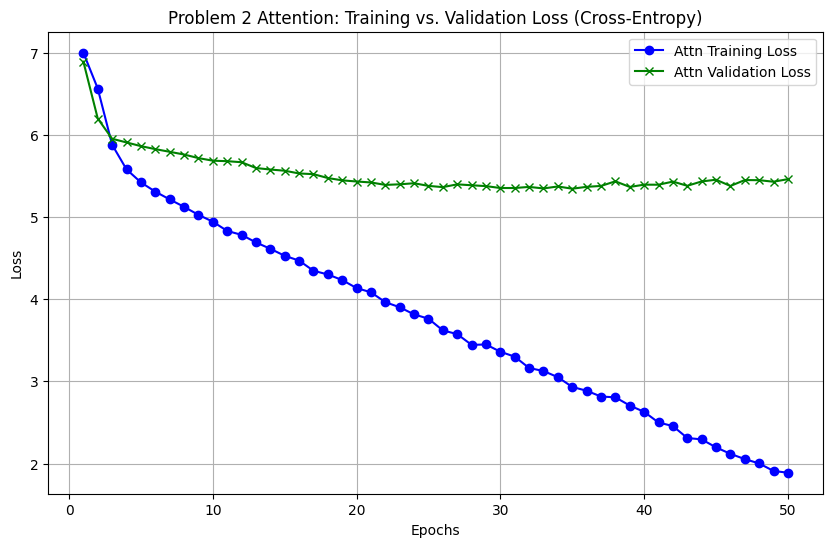

In [9]:
EPOCHS = 50 # Tried 15 first and got: 0.00% accuracy and 0.59 BLEU score, then 150 but it was too high.
LEARNING_RATE = 0.001 # initially 0.001

criterion = nn.CrossEntropyLoss(ignore_index=PAD_token)
optimizer_attn = optim.Adam(model_p2.parameters(), lr=LEARNING_RATE) #, weight_decay=1e-4) # added weight decay to test

# --- Training Functions Brought Over from Problem 1 ---
def train_epoch(model, loader, optimizer, criterion, clip_val=1.0):
    model.train()
    epoch_loss = 0
    for src, trg in loader:
        src, trg = src.to(device), trg.to(device)
        optimizer.zero_grad()
        output = model(src, trg, teacher_forcing_ratio=0.5)
        output_dim = output.shape[-1]
        output = output[1:].view(-1, output_dim) 
        trg = trg[1:].view(-1)
        loss = criterion(output, trg)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), clip_val)
        optimizer.step()
        epoch_loss += loss.item()
    return epoch_loss / len(loader)

def evaluate_epoch(model, loader, criterion):
    model.eval()
    epoch_loss = 0
    with torch.no_grad():
        for src, trg in loader:
            src, trg = src.to(device), trg.to(device)
            output = model(src, trg, teacher_forcing_ratio=0.0)
            output_dim = output.shape[-1]
            output = output[1:].view(-1, output_dim)
            trg = trg[1:].view(-1)
            loss = criterion(output, trg)
            epoch_loss += loss.item()
    return epoch_loss / len(loader)

# --- Execution ---
train_losses_attn = []
val_losses_attn = []

print("Starting Training Loop for Problem 2 (Attention)...")
start_time_attn = time.time()

for epoch in range(EPOCHS):
    train_loss = train_epoch(model_p2, train_loader, optimizer_attn, criterion)
    val_loss = evaluate_epoch(model_p2, val_loader, criterion)
    
    train_losses_attn.append(train_loss)
    val_losses_attn.append(val_loss)
    
    val_perplexity = math.exp(val_loss) if val_loss < 50 else float('inf')
    
    print(f"Epoch: {epoch+1:02} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Perplexity: {val_perplexity:.4f}")

total_train_time_attn = time.time() - start_time_attn
print(f"[*] Total Train Time (s): {total_train_time_attn:.2f}")

# --- Loss Curves Plot ---
plt.figure(figsize=(10, 6))
plt.plot(range(1, EPOCHS+1), train_losses_attn, label='Attn Training Loss', color='blue', marker='o')
plt.plot(range(1, EPOCHS+1), val_losses_attn, label='Attn Validation Loss', color='green', marker='x')
plt.title('Problem 2 Attention: Training vs. Validation Loss (Cross-Entropy)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()
plt.show()

# Evaluation Metrics & Qualitative Validation (Problem 2)
We evaluate the Attention network. The translate_sentence_attn function provides the decoder with the encoder_outputs required for the attention weights, addressing the bottleneck of standard GRUs.

QUALITATIVE VALIDATION SAMPLES (PROBLEM 2 - ATTENTION)
English (Source): She runs in the park
Target (French):  Elle court dans le parc
Model Predicted:  vois dans dans dans le parc
Exact Match:      False | Sent. BLEU: 0.2021
--------------------------------------------------------------------------------
[*] Generating Attention Map for above sentence...


C:\Users\ericv\AppData\Local\Temp\ipykernel_34144\4283275007.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] + source_tokens, rotation=90)
C:\Users\ericv\AppData\Local\Temp\ipykernel_34144\4283275007.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([''] + predicted_tokens)


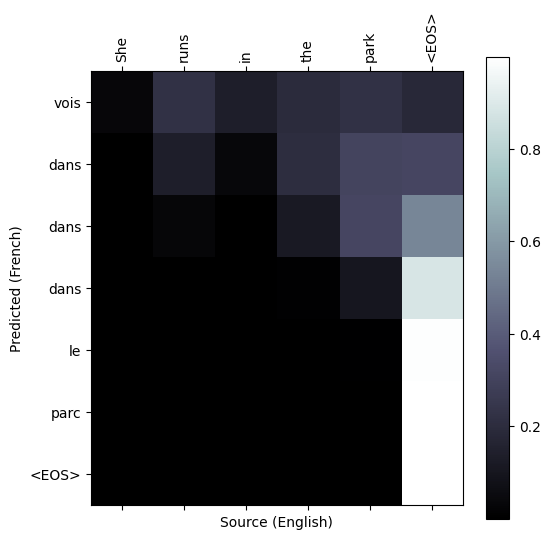

English (Source): He listens to music while jogging
Target (French):  Il écoute de la musique en faisant du jogging
Model Predicted:  fait allés de de du chaque
Exact Match:      False | Sent. BLEU: 0.0294
--------------------------------------------------------------------------------
[*] Generating Attention Map for above sentence...


C:\Users\ericv\AppData\Local\Temp\ipykernel_34144\4283275007.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] + source_tokens, rotation=90)
C:\Users\ericv\AppData\Local\Temp\ipykernel_34144\4283275007.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([''] + predicted_tokens)


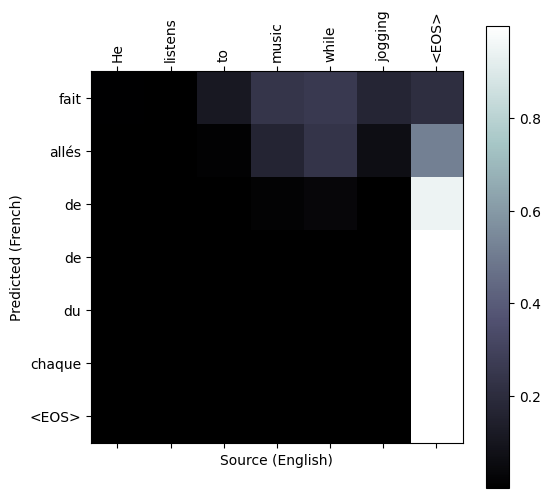

English (Source): She wears a silver necklace
Target (French):  Elle porte un collier en argent
Model Predicted:  porte une une belle de de café
Exact Match:      False | Sent. BLEU: 0.0330
--------------------------------------------------------------------------------
English (Source): You have a spectacular view from your balcony
Target (French):  Vous avez une vue spectaculaire depuis votre balcon
Model Predicted:  a une une belle de de
Exact Match:      False | Sent. BLEU: 0.0293
--------------------------------------------------------------------------------
English (Source): They listen to classical music
Target (French):  Ils écoutent de la musique classique
Model Predicted:  a décidé de la de de
Exact Match:      False | Sent. BLEU: 0.0863
--------------------------------------------------------------------------------
    FINAL VALIDATION METRICS (ATTENTION) 
Traditional Sequence Accuracy : 0.00%
Validation BLEU-4 Score       : 1.05


In [10]:
import matplotlib.ticker as ticker

def plot_attention(attention_matrix, source_tokens, predicted_tokens):
    """Plots a 2D heatmap showing attention weights."""
    fig = plt.figure(figsize=(6, 6))
    ax = fig.add_subplot(111)
    
    cax = ax.matshow(attention_matrix, cmap='bone')
    fig.colorbar(cax)

    # Set axes with tokens
    ax.set_xticklabels([''] + source_tokens, rotation=90)
    ax.set_yticklabels([''] + predicted_tokens)

    # Show label at every tick
    ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
    ax.yaxis.set_major_locator(ticker.MultipleLocator(1))

    plt.xlabel('Source (English)')
    plt.ylabel('Predicted (French)')
    plt.show()

def translate_sentence_attn(model, sentence, input_vocab, output_vocab, device, max_len=50):
    model.eval()
    
    if isinstance(sentence, str):
        tokens = [word for word in sentence.split(' ')]
    else:
        tokens = sentence
        
    indices = [input_vocab.word2index.get(token, UNK_token) for token in tokens] + [EOS_token]
    src_tensor = torch.tensor(indices, dtype=torch.long).unsqueeze(1).to(device)
    
    with torch.no_grad():
        encoder_outputs, hidden = model.encoder(src_tensor)
        
    trg_indexes = [SOS_token]
    
    # MODIFIED: Matrix to store attention scores at each step
    attentions = torch.zeros(max_len, len(indices)).to(device)
    
    for i in range(max_len):
        trg_tensor = torch.tensor([trg_indexes[-1]], dtype=torch.long).unsqueeze(1).to(device)
        
        with torch.no_grad():
            output, hidden, attention = model.decoder(trg_tensor, hidden, encoder_outputs)
            attentions[i] = attention.squeeze(0) # Store the current attention weights
            
            pred_token = output.argmax(1).item()
            trg_indexes.append(pred_token)
            
            if pred_token == EOS_token:
                break
                
    trg_tokens = [output_vocab.index2word[i] for i in trg_indexes]
    predicted_words = trg_tokens[1:] # Drop SOS
    
    # Crop the attention matrix to match the generated length
    attention_matrix = attentions[:len(predicted_words), :].cpu().numpy()
    source_tokens_with_eos = tokens + ['<EOS>']
    
    return predicted_words, attention_matrix, source_tokens_with_eos

def evaluate_attention_model(model, pairs, input_vocab, output_vocab, device, num_display=5):
    exact_matches = 0
    references_bleu = []
    candidates_bleu = []
    plots_generated = 0 # Counter for attention maps
    
    print("="*80)
    print("QUALITATIVE VALIDATION SAMPLES (PROBLEM 2 - ATTENTION)")
    print("="*80)
    
    display_indices = random.sample(range(len(pairs)), num_display)
    
    for i, (eng, fra) in enumerate(pairs):
        pred_tokens_with_eos, attention_matrix, src_tokens_with_eos = translate_sentence_attn(model, eng, input_vocab, output_vocab, device)
        
        # Clean EOS for BLEU/Accuracy calculation
        if pred_tokens_with_eos[-1] == '<EOS>':
            pred_tokens = pred_tokens_with_eos[:-1]
        else:
            pred_tokens = pred_tokens_with_eos
            
        pred_sentence = ' '.join(pred_tokens)
        
        is_exact = (pred_sentence.strip() == fra.strip())
        if is_exact:
            exact_matches += 1
            
        ref_tokens = fra.split(' ')
        references_bleu.append([ref_tokens])
        candidates_bleu.append(pred_tokens)
        
        if i in display_indices:
            cc = SmoothingFunction()
            ind_bleu = nltk.translate.bleu_score.sentence_bleu([ref_tokens], pred_tokens, smoothing_function=cc.method1)
            print(f"English (Source): {eng}")
            print(f"Target (French):  {fra}")
            print(f"Model Predicted:  {pred_sentence}")
            print(f"Exact Match:      {is_exact} | Sent. BLEU: {ind_bleu:.4f}")
            print("-" * 80)
            
            # MODIFIED: Generate exactly 2 plots for the homework requirement
            if plots_generated < 2:
                print("[*] Generating Attention Map for above sentence...")
                plot_attention(attention_matrix, src_tokens_with_eos, pred_tokens_with_eos)
                plots_generated += 1
                
    seq_accuracy = (exact_matches / len(pairs)) * 100
    cc = SmoothingFunction()
    val_bleu4 = corpus_bleu(references_bleu, candidates_bleu, smoothing_function=cc.method1) * 100
    
    print("="*40)
    print("    FINAL VALIDATION METRICS (ATTENTION) ")
    print("="*40)
    print(f"Traditional Sequence Accuracy : {seq_accuracy:.2f}%")
    print(f"Validation BLEU-4 Score       : {val_bleu4:.2f}")
    print("="*40)

evaluate_attention_model(model_p2, val_pairs, eng_vocab, fra_vocab, device)